# 4. Model Validation

This notebook guides you through selecting and validating climate models (CMIP6 and CORDEX) for use in the attribution study.

---

## How to Use This Notebook

**1. Follow the numbered steps in order.**  
Each section builds upon the previous one, from setup, data loading, and climatology computation, to event analysis and visualization.

**2. Look for <font color="orange"> Orange cells  </font> and code cells marked as <font color="lightgreen">##### (User selection) ##### </font>:** 
| <font color="orange"> Orange cells  </font> | <font color="orange"> Need user intervention </font>|
| ----------- | ----------- |
| <font color="green">**Green cells** </font> | <font color="green">**Run automatically on user input provided in the orange cells and should not be adjusted in most cases** </font>|


**3. Run cells sequentially.**  
Start from the top and execute each cell (`Shift` + `Enter`).  

---

## What This Notebook Does

This notebook helps you:
- Load CMIP6 and CORDEX data (daily mean Tmax, Tmean, Tmin, precipitation)
- Validate models based on:
  - Seasonal cycle shape
  - Climatological spatial pattern
  - Distribution fit parameters
- Decide which models to keep for Step 5 (Attribution)

---


### <font color="green">  **Imports** </font>
**Before proceeding, ensure you have executed the cell below.**


In [1]:
# Imports
from c3s_event_attribution_tools import *
import os 
from datetime import datetime, timedelta
import geopandas as gpd
import xarray as xr
from pathlib import Path
import cartopy.crs as ccrs
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
from typing import Dict, Any
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.vectors import ListVector
# import R libraries from WWA
ro.r('''if (!requireNamespace("devtools", quietly = TRUE)) {install.packages("devtools", repos="https://cloud.r-project.org", quiet=TRUE)}''')
ro.r('devtools::install_github("WorldWeatherAttribution/rwwa")')
rwwa = importr("rwwa")
%load_ext rpy2.ipython
from rpy2.robjects import r, globalenv
import rpy2.robjects.pandas2ri as pandas2ri

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console: Using GitHub PAT from the git credential store.
  
R callback write-console: Skipping install of 'rwwa' from a github remote, the SHA1 (236d9a6b) has not changed since last install.
  Use `force = TRUE` to force installation
  


### <font color="orange"> **User specifications** </font>

#### <font color="orange"> Authentication & File Setup </font>

Action Required: Ensure you have entered your **CDS API Key** and **CORDEX ARCO Token** in the code cell above.

Storage: Data and results will be saved to: {{your_save_directory}}.

Security: ⚠️ Never share this notebook publicly or commit it to GitHub with your API keys visible.

Next Step: Once keys are set, run the cell to initialize the DataClient for cloud data access.

In [2]:
# Api key used for the DataClient, replace with your own API key from the C3S Climate Data Store
################# (User selection) ###################
your_api_key = '3cd17835-a572-4a0c-aaeb-334f01427616'
cordex_arco_token = '3683c130-f99a-42ab-9a6e-b4411587136a'
######################################################

# Initialize DataClient
data_client = DataClient(
    cds_key=your_api_key,
    cordex_arco_token=cordex_arco_token
)

# Do not touch
CURRENT_DIRECTORY = os.getcwd() 

# Directory you wish to store output files in, using ../ specifies the parent directory
################# (User selection) ###################
your_save_directory = os.path.abspath(os.path.join(CURRENT_DIRECTORY, "../data"))   # change ../data to your desired directory
######################################################

# Create directory if it does not exist
os.makedirs(your_save_directory, exist_ok=True) 

# Decision table file path
validation_file_path = os.path.join(your_save_directory, "res-models-validation.csv")

#### <font color="orange"> Event Definition & Study Area </font>
Action Required: Define the core parameters for your attribution study. These settings must match the "Event Definition" established in previous steps.

Bounding Box (bbox): Define the spatial extent of the event (South, West, North, East).

Parameter: Select the variable to analyze (Tmean, Tmax, Tmin, or Precipitation).

Event Date: Set the specific date of the extreme event.

Required Files: Ensure the study region shapefile and observed climatology/seasonal cycle datasets are present in your save directory.

In [3]:
################################## (User selection) ##############################################
# Area of interest bounding box:
# (deg Southern boundary, Western boundary, Northern boundary, Eastern boundary)
bbox = (44, -11, 55, 10)

# Choice of parameter (Tmax, Tmean, Tmin, Precipitation)
parameter = 'Tmax'

# Date of the event
event_end = datetime(2025, 7, 10)

## Load study region and data from Event Definition step
# Load study region shapefile
study_region = gpd.read_file(os.path.join(your_save_directory, "sf_studyregion.shp"))

# Load observed seasonal cycle data
obs_seasonal_cycle = xr.open_dataset(os.path.join(your_save_directory, "seasonal_cycle_1991-2020.nc"))

# Load observed climatology data
obs_climatology = xr.open_dataset(os.path.join(your_save_directory, "climatology_1991-2020.nc"))
##################################################################################################

bbox = Utils.convert_bbox(*bbox)
cordex_p = Utils.var_map(parameter, "cordex")
cmip6_p = Utils.var_map(parameter, "cmip6")

# Setting up the parameter specific variables
if parameter in ["Tmax", "Tmean", "Tmin"]:
    variable = "Temperature"
    value_col = "t2m"
    y_label = "c"
    unit = "°C"
    calculation = "absolute"  # absolute or relative
    method = "Mean" 
elif parameter in ["Precipitation"]:
    variable = "Precipitation"
    value_col = "tp"
    y_label = "mm"
    unit = "mm"
    calculation = "relative"  # absolute or relative
    method = "Total"


## <font color="orange"> 4a. List of models </font>

#### <font color="orange"> CMIP6 Selection </font>
**Action Required:** Select the Global Climate Models (GCMs) and time ranges for the CMIP6 ensemble.

- **Model Selection (GCM_models):** Enter the short names of the CMIP6 models you wish to evaluate (e.g., access_cm2, canesm5).

- **Time Ranges:** Define the historical_time_range (baseline) and future_time_range (projections). Per protocol, the future range typically extends to 2100 to capture high-warming scenarios.

- **Experiment:** The default is set to SSP5-8.5 and Historical to represent the full range of forced climate response.

Next Step: Run this cell to fetch the CMIP6 daily data and the corresponding Global Mean Surface Temperature (GMST). The DataClient will automatically pair the climate data with the the corresponding data needed to calculate the GMST required for the non-stationary GEV fitting in Step 5.

In [4]:
models = [
    'access_cm2', 'access_esm1_5', 'awi_cm_1_1_mr', 'awi_esm_1_1_lr', 'bcc_csm2_mr',
    'bcc_esm1', 'cams_csm1_0', 'canesm5', 'canesm5_canoe', 'cesm2', 'cesm2_fv2',
    'cesm2_waccm', 'cesm2_waccm_fv2', 'ciesm', 'cmcc_cm2_hr4', 'cmcc_cm2_sr5',
    'cmcc_esm2', 'cnrm_cm6_1', 'cnrm_cm6_1_hr', 'cnrm_esm2_1', 'e3sm_1_0', 'e3sm_1_1',
    'e3sm_1_1_eca', 'ec_earth3', 'ec_earth3_aerchem', 'ec_earth3_cc', 'ec_earth3_veg',
    'ec_earth3_veg_lr', 'fgoals_f3_l', 'fgoals_g3', 'fio_esm_2_0', 'gfdl_esm4', 'giss_e2_1_g',
    'giss_e2_1_h', 'hadgem3_gc31_ll', 'hadgem3_gc31_mm', 'iitm_esm', 'inm_cm4_8', 'inm_cm5_0',
    'ipsl_cm5a2_inca', 'ipsl_cm6a_lr', 'kace_1_0_g', 'kiost_esm', 'mcm_ua_1_0', 'miroc6',
    'miroc_es2h', 'miroc_es2l', 'mpi_esm_1_2_ham', 'mpi_esm1_2_hr', 'mpi_esm1_2_lr',
    'mri_esm2_0', 'nesm3', 'norcpm1', 'noresm2_lm', 'noresm2_mm', 'sam0_unicon',
    'taiesm1', 'ukesm1_0_ll'
]


In [5]:
############################################### (User selection) ##############################################
# Selected GCM models to run the analysis on
GCM_models = ['access_cm2']
# Limit the maximum number of models to download
max_models = 1
# Future and historical time ranges
future_time_range = (datetime(2015, 1, 1), datetime(2100, 12, 31))
historical_time_range = (datetime(1880, 1, 1), datetime(2014, 12, 31))
# Experiments
experiment = ["ssp5_8_5", "historical"]
###############################################################################################################

#### <font color="orange"> CORDEX Selection </font>

##### <font color="green"> CORDEX domains </font>

Next Step: Run these cells to visualize the domain coverage and build the list of available CORDEX models. The output will show the total number of models found in the catalog that match your selection. This cell automatically compares your Bounding Box and Study Region against CORDEX boundaries to suggest the most suitable domain

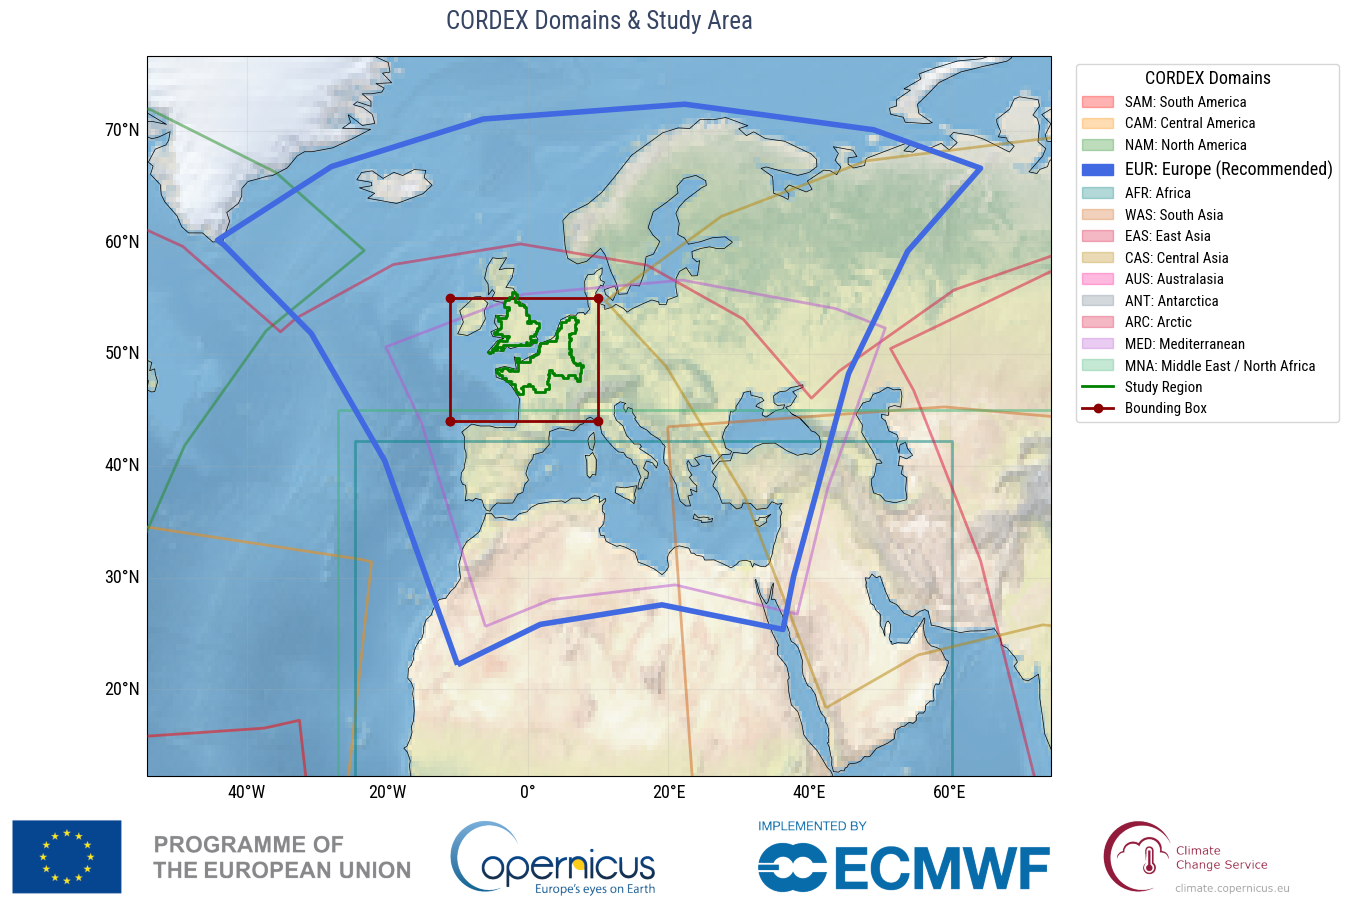

In [6]:
# Process CORDEX domains
mapproj = ccrs.PlateCarree()
domains_data = Utils.get_cordex_domain_configs()
gdf = Utils.create_cordex_gdf(domains_data, mapproj)
selected = Utils.find_covering_domain(gdf, study_region, bbox)
print(f"Selected Domain: {selected} ({domains_data[selected]['long_name']})" if selected else "No single domain fully covers the study area.")
# Plot CORDEX domains
fig, ax, img_ax = Plot.plot_cordex_map(gdf, domains_data, bbox, study_region, mapproj, selected_domain=selected)


##### <font color="orange"> Action Required: </font>

Identify and select the appropriate Regional Climate Model (RCM) domain for your study area. Confirm your selection by entering the domain code (e.g., ["EUR"], ["AFR"], or ["NAM"]).

Model Pairing: The script scans the cloud catalog to find all available GCM-RCM pairings for that specific domain.

In [7]:
############ (User selection) ####################
# Select the CORDEX domain to use for the analysis 
domain = ["EUR"]

# Limit the maximum number of models to download
max_models_ = 1
# Future and historical time ranges
historical_time_range_ = (datetime(1950, 1, 1), datetime(2005, 12, 31))
future_time_range_ = (datetime(2006, 1, 1), datetime(2100, 12, 31))
##################################################

catalog_path = Path(f"{your_save_directory}/projections_cordex_domains_single_levels-ZARR-Access-new.txt")
assert catalog_path.exists(), f"Catalog not found: {catalog_path.resolve()}"

cordex_models = Process.build_cordex_model_pairs(catalog_path, domain)
print(len(cordex_models), 'CORDEX models found for domain', domain, "with max models set to", max_models_)

58 CORDEX models found for domain ['EUR'] with max models set to 1


---

## 4b. Model Validation Procedure

Each model or model ensemble must undergo a validation. Expert judgement is necessary to decide which models are scientifically sound enough to include in the final synthesis. Use the validation table to track your decisions. 

**Important:** You must click the "💾 Save" button to persist your decisions to disk and update the final results table.

### 4b.1 General Properties

Evaluate the model's structural ability to simulate the event by assessing resolution, seasonal cycle, and spatial pattern against the reference observational product.

#### <font color = 'orange'> 4b.1.a Model resolution vs event spatial scale </font>

Is the resolution of the model sufficient to represent the event and for comparison with observations? 

For precipitation, in case of convective precipitation events:
- i. If the event is large scale but convection is clearly present, omit CMIP6 and use only CORDEX.
- ii. If the event is large scale but convection plays a major role (e.g., organised convection), no attribution is possible; exclude CMIP6 and CORDEX.
For precipitation, if the event happens close to an orographic barrier:
- i. Omit CMIP6 and prioritize regional models.

Else: - i. Use both CORDEX and CMIP6.

Please select the models you want to analyse based on the previous statements using **'True'** or **'False'**, then run the cell to download the corresponding models and create the validation table



In [8]:
######################## (User selection) #############################################
# Based on expert judgement of the event scale:
Run_CMIP6 = True   
Run_CORDEX = True  
#######################################################################################

if Run_CMIP6:
    CMIP6_models, CMIP6_GMST = data_client.fetch_climate_scenarios(
        analysis_type='cmip6',
        models=GCM_models,
        variable_name=cmip6_p,
        bbox=bbox,
        hist_range=historical_time_range,
        fut_range=future_time_range
    )

if Run_CORDEX:
    cordex_models, cordex_models_dropped = data_client.fetch_climate_scenarios(
        analysis_type='cordex',
        models=cordex_models,
        variable_name=cordex_p,
        bbox=bbox,
        hist_range=historical_time_range_,
        fut_range=future_time_range_,
        max_models=max_models_
    )


# Create a list to store validation
validation_list = []

# Extract successfully loaded CMIP6 models
if Run_CMIP6:
    for model_id in CMIP6_models.keys():
        validation_list.append({'model': model_id,'project': 'CMIP6', 'Seasonal cycle': '', 'Spatial maps': '', 'sigma_validation' : '', 'shape_validation' : '', 'validation_summary' : '', 'Stat Fit': 'Pending',
        'Comments': '', 'Include T/F' : ''
        })

# Extract successfully loaded CORDEX models
if Run_CORDEX:
    for model_id in cordex_models.keys():
        validation_list.append({'model': model_id, 'project': 'CORDEX', 'Seasonal cycle': '', 'Spatial maps': '', 'sigma_validation' : '', 'shape_validation' : '', 'validation_summary' : '', 'Stat Fit': 'Pending',
        'Comments': '', 'Include T/F' : ''
        })

# Create the DataFrame
df_validation_results = pd.DataFrame(validation_list)


--- Starting CMIP6 Processing (Exp: ssp5_8_5) ---
Processing: access_cm2...
Using locally cached CMIP6 data from CDS.
Using locally cached CMIP6 data from CDS.
   -> Fetching GMST for access_cm2...
Using locally cached CMIP6 data from CDS.
Using locally cached CMIP6 data from CDS.


D:\Git\c3s-451\c3s_event_attribution_tools\data\__init__.py:1159: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gmst_merged = xr.concat([gmst_hist, gmst_fut], dim="time", combine_attrs="override")


   ✅ Success: access_cm2

--- Starting CORDEX Processing (Exp: rcp85) ---
Processing: cccma_canesm2_clmcom_clm_cclm4_8_17...
   -> Fetching GMST for canesm2 (CMIP5)...
      - Historical Period: 185001-200512
Using locally cached data from CDS for 'projections-cmip5-monthly-single-levels'.


D:\Git\c3s-451\c3s_event_attribution_tools\data\__init__.py:1171: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gmst_hist = xr.concat(gmst_hist, dim="time")


      - RCP8.5 Period: 200601-210012
Using locally cached data from CDS for 'projections-cmip5-monthly-single-levels'.


D:\Git\c3s-451\c3s_event_attribution_tools\data\__init__.py:1185: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gmst_fut = xr.concat(gmst_fut, dim="time")


   ✅ Success: cccma_canesm2_clmcom_clm_cclm4_8_17


####  <font color = 'orange'> 4b.1.b. Seasonal Cycle </font>
Does the model seasonal cycle resemble the observed seasonal cycle?

##### <font color = 'green'> Calculations </font>

Run the next cell to compute the corresponding calculations for seasonal cycle, spatial pattern and annual time series. This cell might take a while to finish

In [9]:
if Run_CORDEX:
    CORDEX_analysis = Process.compute_climate_indices(
        data_input=cordex_models,
        parameter=cordex_p,
        study_region=study_region,
        baseline_range=("1991", "2020")
    )

if Run_CMIP6:
    CMIP6_analysis = Process.compute_climate_indices(
        data_input=CMIP6_models,
        parameter=cordex_p,
        study_region=study_region,
        baseline_range=("1991", "2020")
    )

Processing: cccma_canesm2_clmcom_clm_cclm4_8_17
✅ cccma_canesm2_clmcom_clm_cclm4_8_17 Processed successfully.
Processing: access_cm2
✅ access_cm2 Processed successfully.


##### <font color = 'orange'> Cordex Seasonal Cycle </font>
Expert Judgement Criteria:

i. Timing: Do the peaks in the model seasonal cycle correspond to the peaks in observations?

ii. Categorization: Note the seasonal cycle based on the following:

**Good:** Peaks resemble the observed peaks in both timing and magnitude.
**Reasonable:** Peaks resemble the most important features, but some differences exist.
**Bad:** Peaks do not resemble observed peaks.


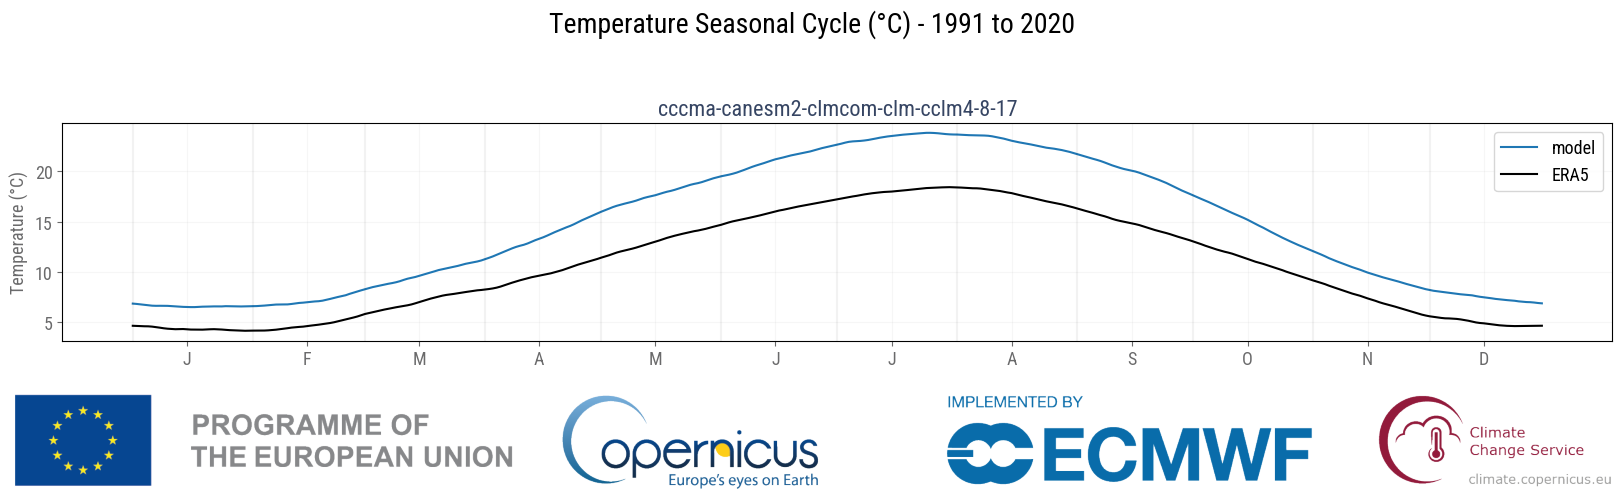

In [10]:
if Run_CORDEX:
    title = f"{variable} Seasonal Cycle ({unit}) - 1991 to 2020"
    legend_title = f"{variable} ({unit})"
    fig, ax, img_ax = Plot.plot_seasonal_cycles(CORDEX_analysis["seasonal_cycles"], obs_seasonal_cycle, value_col=value_col, legend_title=legend_title, title=title)

    # Validation Table update
    Utils.create_decision_hub(df_validation_results, step='seasonal', project_filter='cordex', save_path=validation_file_path)

##### <font color = 'orange'> CMIP6 Seasonal Cycle </font>
Expert Judgement Criteria:

i. Timing: Do the peaks in the model seasonal cycle correspond to the peaks in observations?

ii. Categorization: Note the seasonal cycle based on the following:

**Good:** Peaks resemble the observed peaks in both timing and magnitude.
**Reasonable:** Peaks resemble the most important features, but some differences exist.
**Bad:** Peaks do not resemble observed peaks.


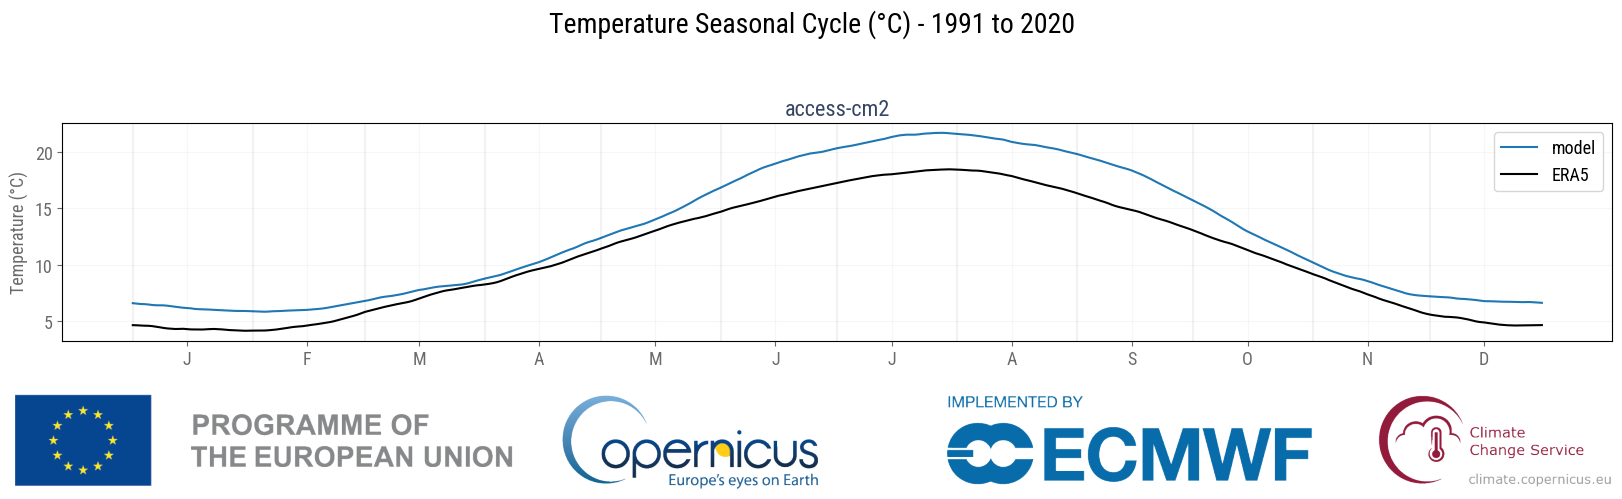

In [11]:
if Run_CMIP6:
    fig, ax, img_ax = Plot.plot_seasonal_cycles(CMIP6_analysis["seasonal_cycles"], obs_seasonal_cycle, value_col=value_col, legend_title=legend_title, title=title)

    # Validation Table update
    Utils.create_decision_hub(df_validation_results, step='seasonal', project_filter='cmip6', save_path=validation_file_path)

#### <font color = 'orange'> 4b.1.c. Spatial Pattern </font>

Does the spatial pattern of the variable - resemble the observed spatial pattern?



##### <font color = 'orange'> Cordex Spatial Pattern </font>
- i.	Note as “good” (main peaks and troughs overlapping in location with observed peaks and troughs, and relative amplitudes of features are ok), “reasonable” (most of the main features are captured) or “bad” (few of the main features are captured). 
- ii.	Write findings and decisions in table.

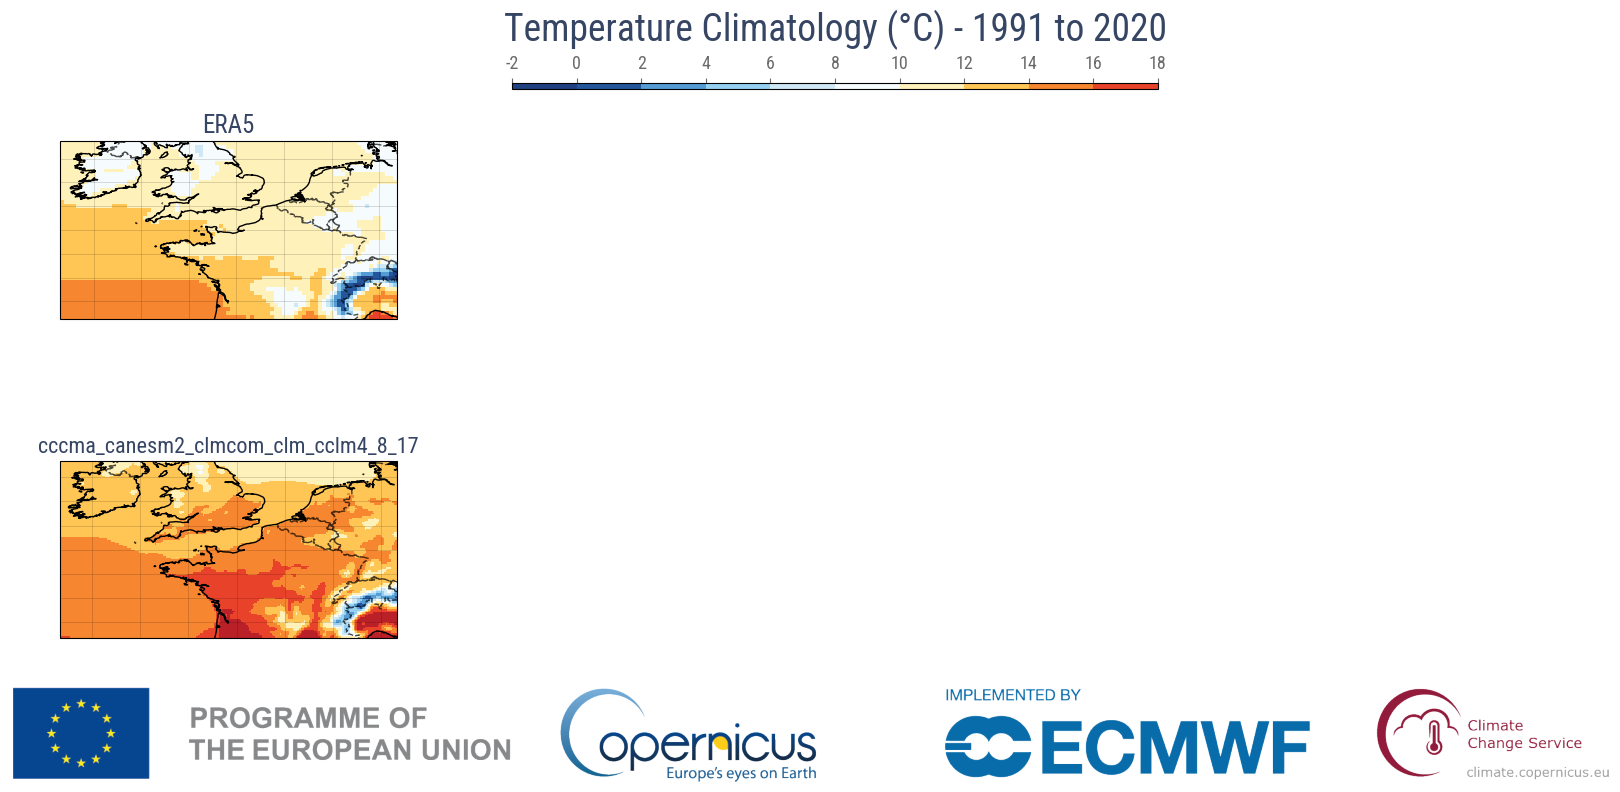

In [12]:
if Run_CORDEX:
    title = f"{variable} Climatology ({unit}) - 1991 to 2020"
    fig, axs, img_ax = Plot.plot_spatial_maps(obs_climatology[value_col], CORDEX_analysis["spatial_maps"], value_col=value_col, legend_title=title)

    # Validation Table update
    Utils.create_decision_hub(df_validation_results, step='spatial', project_filter='cordex', save_path=validation_file_path)

##### <font color = 'orange'> CMIP6 Spatial Pattern </font>
- i.	Note as “good” (main peaks and troughs overlapping in location with observed peaks and troughs, and relative amplitudes of features are ok), “reasonable” (most of the main features are captured) or “bad” (few of the main features are captured). 
- ii.	Write findings and decisions in table.

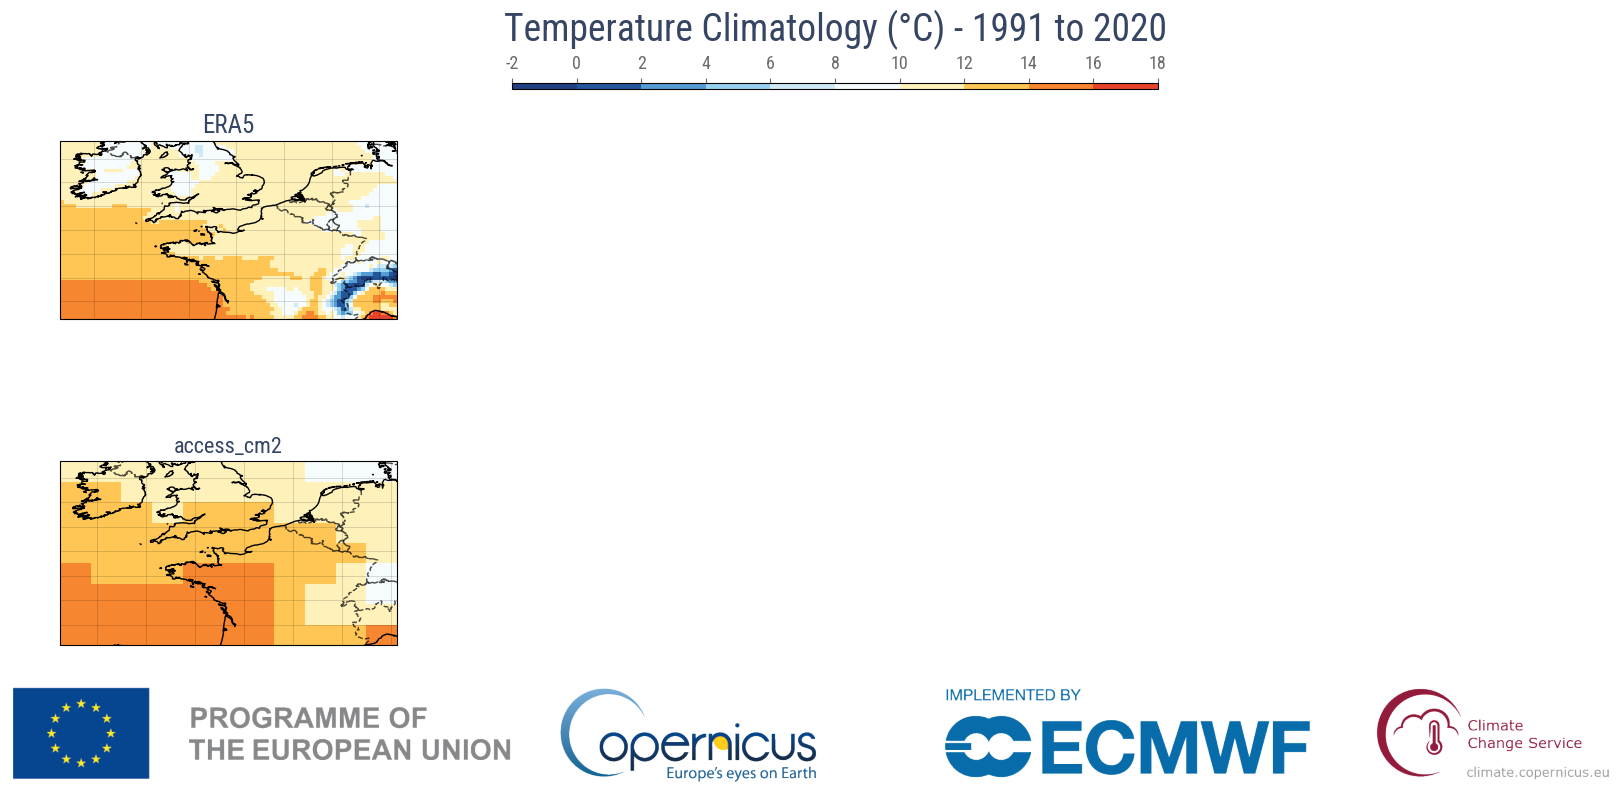

In [13]:
if Run_CMIP6:
    title = f"{variable} Climatology ({unit}) - 1991 to 2020"
    fig, axs, img_ax = Plot.plot_spatial_maps(obs_climatology[value_col], CMIP6_analysis["spatial_maps"], value_col=value_col, legend_title=title)

    # Validation Table update
    Utils.create_decision_hub(df_validation_results, step='spatial', project_filter='cmip6', save_path=validation_file_path)

### 4b.3 Model Time Series


##### <font color='orange'> Parameters and calculation </font>

Choose the same parameters used in Step 1. Event Definition. The yearly time series are calculated based on the selected parameters

In [14]:
################### User Selection  ##################
# Choose mean, max, min
yearly_value = 'max'

# Padding >= 1 : rolling window, n-days (centered)
padding = 3

# Choose month range, e.g. (1, 12) or (12, 1), .. This is still missing in all model validation script!!!!
month_range = (1, 12)

# Standard method for temperature: mean and for precipitation: sum, if not specified
# If you want to change it, specify here
method = 'mean'
#######################################################

if parameter in ["Tmax", "Tmean", "Tmin", "tas"]:
    title = f"Annual time series {variable.capitalize()} ({unit}) - Observational data"
    if method is None:
        method = 'mean'
elif parameter == "Precipitation":
    title = f"Annual time series {variable.capitalize()} ({unit}) - Observational data"
    if method is None:
        method = 'sum'

if Run_CORDEX:
    cordex_yearly_series = Process.calculate_yearly_value_xr(
        time_series=CORDEX_analysis['time_series'], 
        yearly_value=yearly_value, 
        padding=padding
    )
if Run_CMIP6:
    cmip6_yearly_series = Process.calculate_yearly_value_xr(
        time_series=CMIP6_analysis['time_series'], 
        yearly_value=yearly_value, 
        padding=padding
    )

### 4b.4 Model GMST (4-year smoothed)

##### <font color='orange'> Calculations </font>

Run the next cell to compute the corresponding GMST covariates for the different models available

In [15]:
# Assuming CMIP6_GMST is your dictionary of global 'tas' datasets
event_year = event_end.year
if Run_CORDEX:
    cordex_gmst_yearly = Process.compute_gmst_anomalies(
        gmst_dict=cordex_models_dropped,
        event_year=event_year,
        year_range=(1850, 2100)
    )
if Run_CMIP6:
    cmip6_gmst_yearly = Process.compute_gmst_anomalies(
        gmst_dict=CMIP6_GMST,
        event_year=event_year,
        year_range=(1850, 2100)
    )

Calculating GMST anomalies for: cccma_canesm2_clmcom_clm_cclm4_8_17
✅ GMST anomaly calculated (Ref 2025: 15.59°C)
Calculating GMST anomalies for: access_cm2
✅ GMST anomaly calculated (Ref 2025: 15.21°C)


### 4b.5 Statistical properties and probabilistic attribution


#### <font color='green'> a. Parameters </font>

Use the same statistical model (e.g. Gauss/GEV/..., shift/scale) as in observations. After running this cell, you will plot the annual time series from observations. Additionally, some neccesary computations are run as conversions and setting up specific parameters



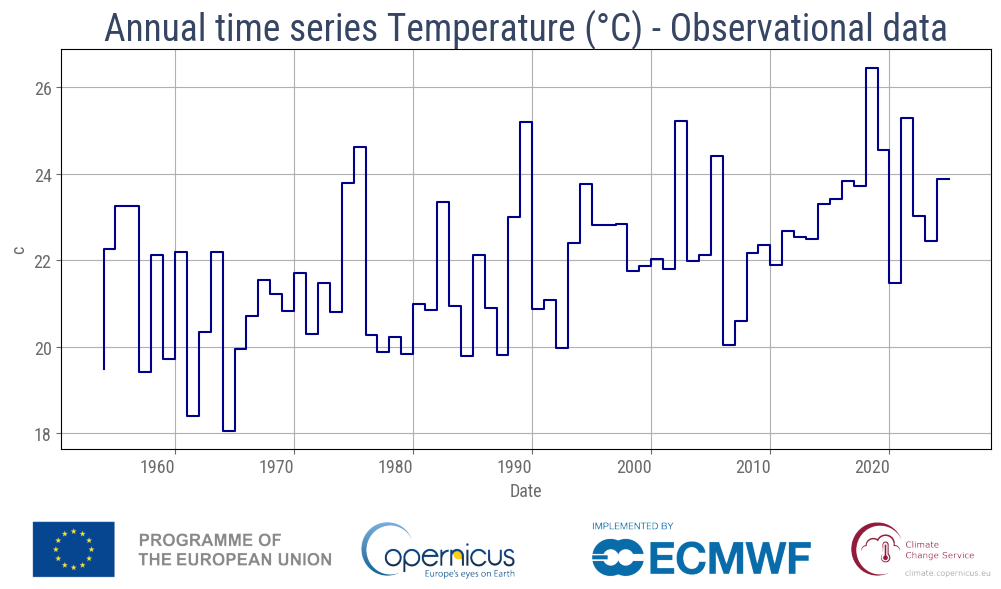

In [16]:
################# (User selection) ###################
annual_timeseries_load = 'ts_ann_studyregion.nc'

start_year = 1954
end_year = 2025
######################################################
ts_ann_studyregion = xr.open_dataset(os.path.join(your_save_directory, annual_timeseries_load))

ts_ann_studyregion = ts_ann_studyregion['t2m'].to_dataframe().reset_index()
ts_ann_studyregion['year'] = pd.to_datetime(ts_ann_studyregion['year'].astype(int), format='%Y')

year_range = (start_year, end_year)

#drop from a range of years if needed
ts_ann_studyregion = Utils.subset_gdf(ts_ann_studyregion, datetime_col='year', year_range=year_range)
ts_ann_studyregion['year'] = ts_ann_studyregion['year'].dt.year
ts_ann_studyregion

fig, ax, img_ax = Plot.plot_timeserie(data=ts_ann_studyregion, value_col=value_col,
                                 datetime_col='year', title=title, x_label='Date',
                                 y_label=y_label, line_style='-', draw_style='steps')

# Convert annual time series to dataframes
if Run_CORDEX:
    cordex_model_dfs = Utils.convert_series_to_dfs(cordex_yearly_series)
if Run_CMIP6:
    cmip6_model_dfs = Utils.convert_series_to_dfs(cmip6_yearly_series)

# Setting up the parameter specific variables
if parameter in ["Tmax", "Tmean", "Tmin", "tas"]:
    method = "std" 
elif parameter == "Precipitation": 
    method = "dispersion"


#### <font color='green'> b.	Scale and dispersion </font>

Plot and visually check the scale or dispersion parameter of the annual maximum time series. Add a sentence on caution to the scientific report Section 4

In [ ]:
print(f"Calculating 15-year rolling window test using method: {method}")
obs_ann_15ym = Process.calculate_rolling_window(gdf=ts_ann_studyregion, value_col=value_col, datetime_col="year",
                                  window=15, method=method, min_periods=1, centering=True, ci=0.95)

cmip6_model_dfs_15ym = {}
cordex_model_dfs_15ym = {}
if Run_CMIP6:
    for name, df in cmip6_model_dfs.items():
        cmip6_model_dfs_15ym[name] = Process.calculate_rolling_window(gdf=df, value_col='value', datetime_col="year",
                                    window=15, method=method, min_periods=1, centering=True, ci=0.95)
if Run_CORDEX:
    for name, df in cordex_model_dfs.items():
        cordex_model_dfs_15ym[name] = Process.calculate_rolling_window(gdf=df, value_col='value', datetime_col="year",
                                    window=15, method=method, min_periods=1, centering=True, ci=0.95)
    

Calculating 15-year rolling window test using method: std


##### <font color='green'> CORDEX yearly time series </font>

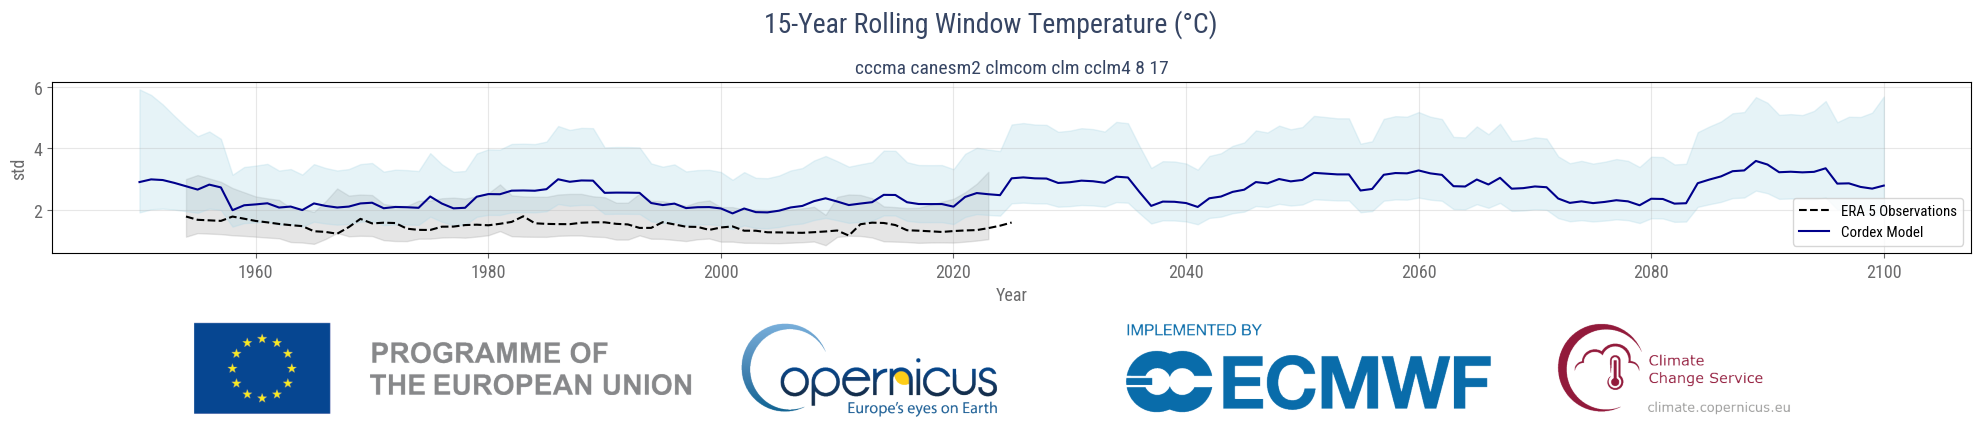

In [18]:
if Run_CORDEX:
    fig, axs, img_ax = Plot.plot_rolling_window_comparison(
        model_dfs=cordex_model_dfs_15ym, 
        obs_df=obs_ann_15ym, 
        value_col=value_col,
        legend_title=f"15-Year Rolling Window {variable} ({unit})",
        yaxis_label=method
    )
    Utils.create_decision_hub(df_validation_results, step='visual', project_filter='cordex', save_path=validation_file_path)


##### <font color='green'> CMIP6 yearly time series </font>

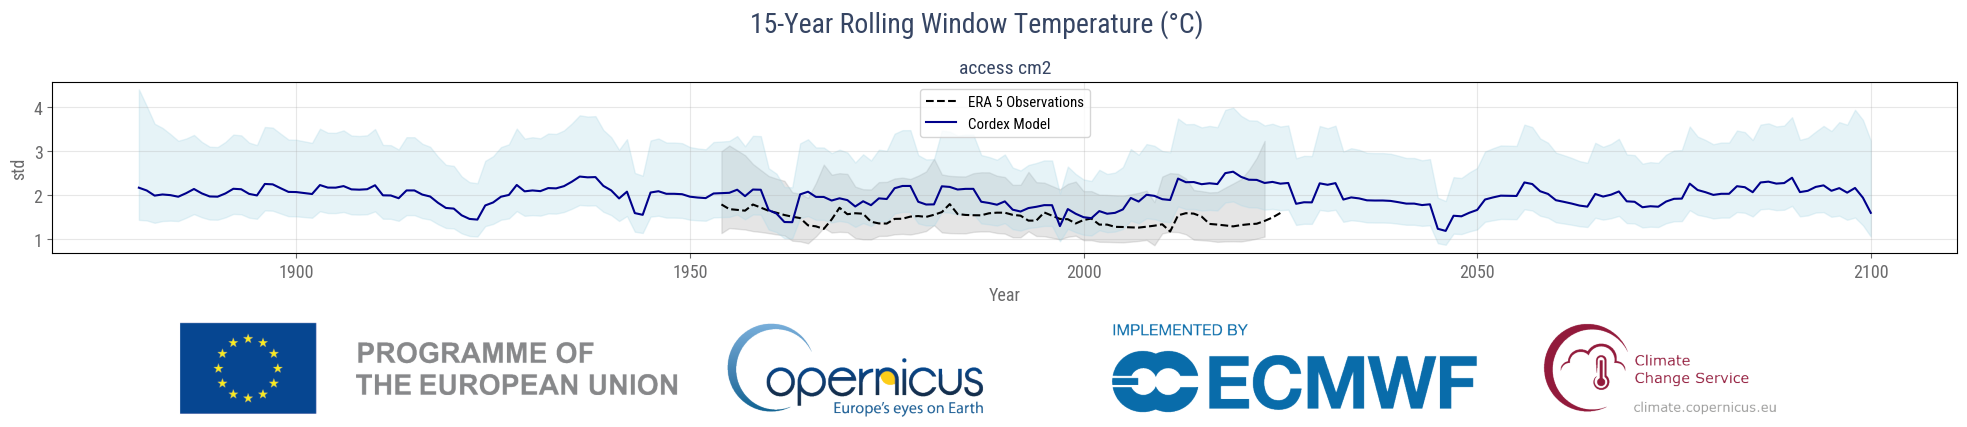

In [19]:
if Run_CMIP6:
    fig, axs, img_ax = Plot.plot_rolling_window_comparison(
        model_dfs=cmip6_model_dfs_15ym, 
        obs_df=obs_ann_15ym, 
        value_col=value_col,
        legend_title=f"15-Year Rolling Window {variable} ({unit})",
        yaxis_label=method
    )
    Utils.create_decision_hub(df_validation_results, step='visual', project_filter='cordex', save_path=validation_file_path)

#### 5. Probabilistic Attribution

This section details the probabilistic attribution analysis. While only models that pass the validation in Step 4 are included in the final report, it is more efficient to perform the analysis on all models first. Therefore, Step 5 is executed here to generate results for all models and scenarios, providing the necessary data to complete the statistical validation and selection criteria in Step 4b.5.

##### <font color="green"> Initialize functions and R dataframes </font>

In [20]:
# Initialize empty dictionaries for all models
combined_model_dfs = {}
combined_gmst_dfs = {}

# Add CORDEX if enabled
if Run_CORDEX:
    for key, df in cordex_model_dfs.items():
        combined_model_dfs[key] = df
        combined_gmst_dfs[key] = cordex_gmst_yearly[key]

# Add CMIP6 if enabled (merging into the same dicts)
if Run_CMIP6:
    for key, df in cmip6_model_dfs.items():
        combined_model_dfs[key] = df
        combined_gmst_dfs[key] = cmip6_gmst_yearly[key]

# Convert the unified dictionaries to R objects once
combined_models_r = {}
combined_gmst_r = {}

for key, df in combined_model_dfs.items():
    with localconverter(ro.default_converter + pandas2ri.converter):
        combined_models_r[key] = ro.conversion.py2rpy(df)
        combined_gmst_r[key] = ro.conversion.py2rpy(combined_gmst_dfs[key])

# Push to R environment
ro.globalenv["all_models_r"] = ListVector(combined_models_r)
ro.globalenv["all_gmst_r"] = ListVector(combined_gmst_r)

# Call R functions
Process.analyze_extreme_scenario()
analyze_extreme_scenario = r['analyze_extreme_scenario']

Process.merge_model_gmst()
merge_model_gmst = r['merge_model_gmst']


##### <font color='orange'> Model fitting </font>

Model fitting is performed three times (utilizing the same fit for both future scenarios), using each model’s smoothed GMST as a covariate. Please validate the selection of the return period ($rp$), the number of bootstrap samples ($nsamp$) for uncertainty estimation, and the specific scenarios to be executed.

**Note:** For CORDEX models, the "Past-Full" scenario is omitted, as the available data period matches the "Validation" scenario baseline.

In [21]:
%%R -i your_save_directory

############################ User Selection ############################
rp <- 1.78  # Your chosen Return Period (e.g., from Obs)
nsamp <- 10 # Samples for uncertainty

scenarios <- list(
        list(ys=1950, ye=2025, yn=2025, dG=0,   lbl="Validation"),
        list(ys=1880, ye=2025, yn=2025, dG=0,   lbl="Past-Full"),
        list(ys=1880, ye=2100, yn=2025, dG=0.7, lbl="Future-2.0"),
        list(ys=1880, ye=2100, yn=2025, dG=1.3, lbl="Future-2.6")
    )

########################################################################

# Setup
library(rwwa)
library(extRemes)
all_scenarios_results <- list()
counter <- 1
# Loop through the combined list (contains both CORDEX and CMIP6)
for (name in names(all_models_r)) {
    cat("Processing Model:", name, "\n")
    
    m_df <- all_models_r[[name]]
    g_df <- all_gmst_r[[name]]

    data_start_year <- min(m_df$year, na.rm = TRUE)
    is_recent_model <- data_start_year >= 1950
    
    for (s in scenarios) {

        if (s$lbl == "Past-Full" && is_recent_model) {
            cat("   Skipping Past-Full for", name, "(Data starts in", data_start_year, ")\n")
            next
        }
        res <- analyze_extreme_scenario(name, rp, m_df, g_df, s$ys, s$ye, s$yn, nsamp, s$dG, s$lbl, your_save_directory)
        
        if (!is.null(res)) {
            all_scenarios_results[[counter]] <- res
            counter <- counter + 1
        }
    }
}

# Save everything to ONE file
if (length(all_scenarios_results) > 0) {
    df_final <- do.call(rbind, all_scenarios_results)
    df_final$Include <- TRUE
    
    # Reorder columns: meta data first
    meta_cols <- c("Include", "model", "scenario")
    data_cols <- setdiff(names(df_final), meta_cols)
    df_final <- df_final[, c(meta_cols, data_cols)]

    out_file <- file.path(your_save_directory, "res-models-all.csv")
    write.csv(df_final, out_file, row.names = FALSE, quote = FALSE)
    
    cat("\n✅ Success! Saved all CMIP6 and CORDEX results to:", out_file, "\n")
} else {
    cat("\n❌ No results were generated. Check your data input.\n")
}

Processing Model: cccma_canesm2_clmcom_clm_cclm4_8_17 
   Scenario [Validation]: Years 1950-2025
   Skipping Past-Full for cccma_canesm2_clmcom_clm_cclm4_8_17 (Data starts in 1950 )
   Scenario [Future-2.0]: Years 1880-2100
   Scenario [Future-2.6]: Years 1880-2100
Processing Model: access_cm2 
   Scenario [Validation]: Years 1950-2025
   Scenario [Past-Full]: Years 1880-2025
   Scenario [Future-2.0]: Years 1880-2100
   Scenario [Future-2.6]: Years 1880-2100

<U+2705> Success! Saved all CMIP6 and CORDEX results to: d:\Git\c3s-451\data/res-models-all.csv 


#### d.	Compare statistical fit 

Compare statistical fit parameters over a period as similar as possible to the observed data: for ‘now’, or spanning the same historical period (e.g. 1950-now). Check findings in the automated output table and combine with general properties into one conclusion.


##### <font color='green'>  Extract observational data </font>

In [22]:
df_obs = pd.read_csv(f'{your_save_directory}/res-obs_era5.csv', index_col=0)
df_validation = pd.read_csv(os.path.join(your_save_directory, "res-models-all.csv"))

# Extract reference dictionaries for Sigma and Shape
obs_sigma = {
    'est':   df_obs.loc['era5', 'sigma0_est'],
    'lower': df_obs.loc['era5', 'sigma0_lower'],
    'upper': df_obs.loc['era5', 'sigma0_upper']
}
obs_shape = {
    'est':   df_obs.loc['era5', 'shape_est'],
    'lower': df_obs.loc['era5', 'shape_lower'],
    'upper': df_obs.loc['era5', 'shape_upper']
}
obs_return_period = df_obs.loc['era5', 'return_period_est']

obs_event_magnitude = df_obs.loc['era5', 'event_magnitude_est']

# Run the sync
Utils.extract_results(parameter, df_validation_results, df_validation, obs_sigma, obs_shape, obs_return_period, obs_event_magnitude)

##### <font color='orange'> Take a decision over results </font>

Assess the statistical consistency between the model and observations using the fit parameters ($\sigma$ and $\xi$). Use the following criteria for inclusion:
- i. Good: The best estimates of the model fit parameters fall within the observed confidence intervals.
- ii. Reasonable: The confidence intervals of the model and observations partially overlap (minimum 5% overlap);
- iii. Bad: The confidence intervals do not overlap; exclude these models from the synthesis.

Additionally, evaluate the magnitude difference at the specified return period to assess bias. Exclude model runs requiring excessive bias correction that results in an unphysical or significantly divergent event magnitude compared to observations.

In [23]:
Utils.create_decision_hub(df_validation_results, step='statistics', project_filter='all', save_path=validation_file_path)

### <font color='orange'> 4b.6 Decide on which models to include  </font>

Decide on which models to includein the model synthesis. Note that if we have enough “good” models we can discuss whether we want to do the synthesis without including the "reasonable" models. If we still use the "reasonable" ones this should be noted as a caution in the associated text.
- a.	If, per framing/model setup we have five or more models (from a different model ensemble) that are “good” according to the validation we do not use the “reasonable” models for that framing/model setup but only the “good” models. If we have less than five “good” models, first add only models with one “reasonable”, if still less than five models add models with two “reasonable” labels, etc.
- b.	If we have two models stemming from the same model, e.g., a high and a lower resolution model, check (by eye) if the results in the attribution step are the same. If so, only use one of the models, otherwise keep both.
- c.	In the scientific report the conclusion will appear in the table with values as ‘yes’ (good), ‘yes (just)’ (reasonable) or ‘no’ (bad).
- d.	All decisions that deviate from the above points need to be documented including the reason of the decision.


In [24]:
Utils.create_decision_hub(df_validation_results, step='full', project_filter='all', save_path=validation_file_path)

### 4.7 State other considerations for including or excluding models

Other considerations for including or excluding a model must be clearly documented, explicitly stating the decisions and motivation for the decision in the validation output table or scientific report Sec 4.

### <font color='orange'> 4b.8 Decide on which models to include  </font>

Fill column “Include Y/N” for each model with the decision to include “Y” or exclude “N” the model.

In [25]:
Utils.create_decision_hub(df_validation_results, step='full', project_filter='all', save_path=validation_file_path)

##### <font color='orange'> Save outputs </font>
Run the cell below to combine all your decisions in the output file used for the next step (6. Synthesis)

In [26]:
# Final decision map
decision_map = df_validation_results.set_index('model')['Include T/F'].to_dict()

# Map decisions and set index
df_validation_final = df_validation.copy()
df_validation_final['Include'] = df_validation_final['model'].map(decision_map)
df_validation_final.set_index('model', inplace=True)
df_validation_final.index.name = None

# Save the full file
full_path = os.path.join(your_save_directory, "res-models-final-decisions.csv")
df_validation_final.to_csv(full_path, index=True)

# Create and save the Future-2.0 file
df_20 = df_validation_final[df_validation_final['scenario'] == 'Future-2.0']
df_20 = df_20.drop(columns=['scenario'])
path_20 = os.path.join(your_save_directory, "res-models-Future-2.0.csv")
df_20.to_csv(path_20, index=True)

# Create and save the Future-2.6 file
df_26 = df_validation_final[df_validation_final['scenario'] == 'Future-2.6']
df_26 = df_26.drop(columns=['scenario'])
path_26 = os.path.join(your_save_directory, "res-models-Future-2.6.csv")
df_26.to_csv(path_26, index=True)

print(f"✅ Three files saved successfully in: {your_save_directory}")
print(f"1. Full: {os.path.basename(full_path)}")
print(f"2. Scen 2.0: {os.path.basename(path_20)}")
print(f"3. Scen 2.6: {os.path.basename(path_26)}")

✅ Three files saved successfully in: d:\Git\c3s-451\data
1. Full: res-models-final-decisions.csv
2. Scen 2.0: res-models-Future-2.0.csv
3. Scen 2.6: res-models-Future-2.6.csv
